In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("dialog_dataset")

FILE_PATHS = {
    "train": DATA_DIR / "train.csv",
    "validation": DATA_DIR / "validation.csv",
    "test": DATA_DIR / "test.csv",
}

DIALOGUE_COL = "dialogue"
SUMMARY_COL = "summary"

Кількість рядків у train, validation і test

In [4]:
splits = {}

for split_name, file_path in FILE_PATHS.items():
    if not file_path.exists():
        raise FileNotFoundError(
            f"Файл для split '{split_name}' не знайдено: {file_path}"
        )

    splits[split_name] = pd.read_csv(file_path)

    print(
        f"{split_name}: "
        f"{splits[split_name].shape[0]} рядків, "
        f"{splits[split_name].shape[1]} колонок"
    )

train: 12460 рядків, 4 колонок
validation: 500 рядків, 4 колонок
test: 1500 рядків, 4 колонок


In [5]:
for split_name, df in splits.items():
    print(f"\n{split_name.upper()}")
    print("Колонки:", list(df.columns))


TRAIN
Колонки: ['id', 'dialogue', 'summary', 'topic']

VALIDATION
Колонки: ['id', 'dialogue', 'summary', 'topic']

TEST
Колонки: ['id', 'dialogue', 'summary', 'topic']


Приклади діалогів

In [6]:
for split_name, df in splits.items():
    print(f"\n===== {split_name.upper()} =====")

    display(
        df[[DIALOGUE_COL, SUMMARY_COL]].head(2)
    )


===== TRAIN =====


,dialogue,summary
0,"#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. ...","Mr. Smith's getting a check-up, and Doctor Haw..."
1,"#Person1#: Hello Mrs. Parker, how have you bee...",Mrs Parker takes Ricky for his vaccines. Dr. P...



===== VALIDATION =====


,dialogue,summary
0,"#Person1#: Hello, how are you doing today?\n#P...",#Person2# has trouble breathing. The doctor as...
1,#Person1#: Hey Jimmy. Let's go workout later t...,#Person1# invites Jimmy to go workout and pers...



===== TEST =====


,dialogue,summary
0,"#Person1#: Ms. Dawson, I need you to take a di...",Ms. Dawson helps #Person1# to write a memo to ...
1,"#Person1#: Ms. Dawson, I need you to take a di...",In order to prevent employees from wasting tim...


In [7]:
def add_eda_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    dialogues = (
        result[DIALOGUE_COL]
        .fillna("")
        .astype(str)
    )

    summaries = (
        result[SUMMARY_COL]
        .fillna("")
        .astype(str)
    )

    result["dialogue_words"] = (
        dialogues.str.split().str.len()
    )

    result["summary_words"] = (
        summaries.str.split().str.len()
    )

    result["dialogue_chars"] = dialogues.str.len()
    result["summary_chars"] = summaries.str.len()

    result["num_turns"] = dialogues.apply(
        lambda text: sum(
            bool(line.strip())
            for line in text.splitlines()
        )
    )

    result["compression_ratio"] = np.where(
        result["dialogue_words"] > 0,
        result["summary_words"]
        / result["dialogue_words"],
        np.nan,
    )

    return result


eda_splits = {
    split_name: add_eda_features(df)
    for split_name, df in splits.items()
}

Загальна статистика по оригінальних датасетах

In [8]:
def summarize_split(
    split_name: str,
    df: pd.DataFrame,
) -> dict:
    dialogue_text = (
        df[DIALOGUE_COL]
        .fillna("")
        .astype(str)
    )

    summary_text = (
        df[SUMMARY_COL]
        .fillna("")
        .astype(str)
    )

    return {
        "split": split_name,
        "examples": len(df),

        "missing_dialogues": (
            df[DIALOGUE_COL].isna().sum()
        ),
        "missing_summaries": (
            df[SUMMARY_COL].isna().sum()
        ),

        "empty_dialogues": (
            dialogue_text.str.strip().eq("").sum()
        ),
        "empty_summaries": (
            summary_text.str.strip().eq("").sum()
        ),

        "duplicate_pairs": (
            df.duplicated(
                subset=[DIALOGUE_COL, SUMMARY_COL]
            ).sum()
        ),
        "duplicate_dialogues": (
            df.duplicated(
                subset=[DIALOGUE_COL]
            ).sum()
        ),

        "mean_dialogue_words": (
            df["dialogue_words"].mean()
        ),
        "median_dialogue_words": (
            df["dialogue_words"].median()
        ),
        "p95_dialogue_words": (
            df["dialogue_words"].quantile(0.95)
        ),
        "max_dialogue_words": (
            df["dialogue_words"].max()
        ),

        "mean_summary_words": (
            df["summary_words"].mean()
        ),
        "median_summary_words": (
            df["summary_words"].median()
        ),
        "p95_summary_words": (
            df["summary_words"].quantile(0.95)
        ),
        "max_summary_words": (
            df["summary_words"].max()
        ),

        "median_turns": (
            df["num_turns"].median()
        ),
        "p95_turns": (
            df["num_turns"].quantile(0.95)
        ),
        "max_turns": (
            df["num_turns"].max()
        ),

        "mean_compression_ratio": (
            df["compression_ratio"].mean()
        ),
        "median_compression_ratio": (
            df["compression_ratio"].median()
        ),
    }


summary_rows = [
    summarize_split(split_name, df)
    for split_name, df in eda_splits.items()
]

split_summary = (
    pd.DataFrame(summary_rows)
    .round(2)
)

display(split_summary)

,split,examples,missing_dialogues,missing_summaries,empty_dialogues,empty_summaries,duplicate_pairs,duplicate_dialogues,mean_dialogue_words,median_dialogue_words,...,max_dialogue_words,mean_summary_words,median_summary_words,p95_summary_words,max_summary_words,median_turns,p95_turns,max_turns,mean_compression_ratio,median_compression_ratio
0,train,12460,0,0,0,0,0,2,130.99,116.0,...,985,22.87,21.0,42.0,153,9.0,16.0,61,0.19,0.18
1,validation,500,0,0,0,0,0,0,129.34,115.0,...,472,20.91,18.0,39.0,65,9.0,16.0,29,0.17,0.17
2,test,1500,0,0,0,0,10,1000,134.46,120.0,...,789,18.75,17.0,35.0,84,9.0,16.0,65,0.15,0.14


In [9]:
def normalize_text(text: object) -> str:
    text = str(text)
    text = " ".join(text.split())
    return text.casefold()

In [10]:
normalized_dialogues = {}

for split_name, df in splits.items():
    values = (
        df[DIALOGUE_COL]
        .fillna("")
        .apply(normalize_text)
    )

    normalized_dialogues[split_name] = {
        value
        for value in values
        if value
    }

Перевірка, чи якісь діалоги перетинаються між датасетами

In [11]:
overlap_results = pd.DataFrame(
    [
        {
            "comparison": "train ↔ validation",
            "overlapping_dialogues": len(
                normalized_dialogues["train"]
                & normalized_dialogues["validation"]
            ),
        },
        {
            "comparison": "train ↔ test",
            "overlapping_dialogues": len(
                normalized_dialogues["train"]
                & normalized_dialogues["test"]
            ),
        },
        {
            "comparison": "validation ↔ test",
            "overlapping_dialogues": len(
                normalized_dialogues["validation"]
                & normalized_dialogues["test"]
            ),
        },
    ]
)

display(overlap_results)

,comparison,overlapping_dialogues
0,train ↔ validation,33
1,train ↔ test,1
2,validation ↔ test,6


Такі випадки було знайдено, тому видаляємо їх з validation і test датасетів

In [12]:
for split_name, df in splits.items():
    df["normalized_dialogue"] = (
        df[DIALOGUE_COL]
        .fillna("")
        .apply(normalize_text)
    )

In [13]:
train_val_overlap = splits["train"].merge(
    splits["validation"],
    on="normalized_dialogue",
    suffixes=("_train", "_validation"),
)

print("Кількість:", len(train_val_overlap))

display(
    train_val_overlap[
        [
            "normalized_dialogue",
            f"{SUMMARY_COL}_train",
            f"{SUMMARY_COL}_validation",
        ]
    ].head(10)
)

Кількість: 33


,normalized_dialogue,summary_train,summary_validation
0,#person1#: i have to do some shopping. #person...,#Person1# wants a new bedroom set. #Person2# t...,#Person1# wants to buy a new bedroom set but d...
1,#person1#: what happened? why didn't he win? #...,#Person2# tells #Person1# the athlete was disq...,#Person2# tells #Person1# a talented athlete d...
2,#person1#: we really were lucky. we got the la...,#Person1# and #Person2# are lucky to get the l...,#Person1# and #Person2# are discussing what to...
3,"#person1#: listen, karen, i need your help. i ...",#Person1# and Hank will fly to LA to see her s...,#Person1# asks Karen for help to find a mature...
4,"#person1#: so, emily, how was your day? #perso...",Emily tells #Person1# she had a horrible day. ...,Emily tells #Person1# that she had a bad day b...
5,#person1#: i don't think the teacher had a rig...,#Person1# thinks the teacher shouldn't accuse ...,Both #Person1# and #Person2# think the teacher...
6,#person1#: some people pile on their agonise a...,#Person1# tells #Person2# the experience of be...,#Person1# and #Person2# talk about people taki...
7,#person1#: let's call it a day. #person2#: it'...,#Person1# and #Person2# got home late for the ...,Both #Person1# and #Person2# hate the evening ...
8,#person1#: mary? are you still there? #person2...,#Person1# inquires Mary about her bid. Mary is...,#Person1# asks Mary the result of the bid not ...
9,#person1#: that china-gown of tang-dynasty sty...,#Person1# tries on a China-gown of Tang-Dynast...,#Person1# tries on a little tight China-gown a...


In [14]:
train_test_overlap = splits["train"].merge(
    splits["test"],
    on="normalized_dialogue",
    suffixes=("_train", "_test"),
)

print("Кількість:", len(train_test_overlap))

display(
    train_test_overlap[
        [
            "normalized_dialogue",
            f"{SUMMARY_COL}_train",
            f"{SUMMARY_COL}_test",
        ]
    ]
)

Кількість: 3


,normalized_dialogue,summary_train,summary_test
0,"#person1#: it's a lovely day, isn't it? #perso...",#Person2# tells #Person1# that #Person2# likes...,#Person2# likes his neibourhood girl who is po...
1,"#person1#: it's a lovely day, isn't it? #perso...",#Person2# tells #Person1# that #Person2# likes...,#Person2# tells #Person1# that he falls in lov...
2,"#person1#: it's a lovely day, isn't it? #perso...",#Person2# tells #Person1# that #Person2# likes...,#Person2# tells #Person1# he falls in love wit...


In [15]:
train_clean = splits["train"].copy()

train_dialogues = set(
    train_clean["normalized_dialogue"]
)

validation_clean = splits["validation"][
    ~splits["validation"]["normalized_dialogue"].isin(
        train_dialogues
    )
].copy()

validation_dialogues = set(
    validation_clean["normalized_dialogue"]
)

test_clean = splits["test"][
    ~splits["test"]["normalized_dialogue"].isin(
        train_dialogues | validation_dialogues
    )
].copy()

In [16]:
print(
    "Train:",
    len(splits["train"]),
    "→",
    len(train_clean),
)

print(
    "Validation:",
    len(splits["validation"]),
    "→",
    len(validation_clean),
)

print(
    "Test:",
    len(splits["test"]),
    "→",
    len(test_clean),
)

Train: 12460 → 12460
Validation: 500 → 467
Test: 1500 → 1479


In [17]:
clean_dialogues = {
    "train": set(train_clean["normalized_dialogue"]),
    "validation": set(
        validation_clean["normalized_dialogue"]
    ),
    "test": set(test_clean["normalized_dialogue"]),
}

print(
    "Train ↔ Validation:",
    len(
        clean_dialogues["train"]
        & clean_dialogues["validation"]
    ),
)

print(
    "Train ↔ Test:",
    len(
        clean_dialogues["train"]
        & clean_dialogues["test"]
    ),
)

print(
    "Validation ↔ Test:",
    len(
        clean_dialogues["validation"]
        & clean_dialogues["test"]
    ),
)

Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0


Зберігаємо очищені датасети - саме їх будемо використовувати для моделі

In [18]:
from pathlib import Path

CLEAN_DATA_DIR = Path("dialog_dataset/cleaned")
CLEAN_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Папка для очищених даних:", CLEAN_DATA_DIR)

Папка для очищених даних: dialog_dataset\cleaned


In [19]:
def prepare_for_saving(df):
    return (
        df.drop(
            columns=["normalized_dialogue"],
            errors="ignore",
        )
        .reset_index(drop=True)
    )


train_final = prepare_for_saving(train_clean)
validation_final = prepare_for_saving(validation_clean)
test_final = prepare_for_saving(test_clean)

In [20]:
train_final.to_csv(
    CLEAN_DATA_DIR / "train_clean.csv",
    index=False,
)

validation_final.to_csv(
    CLEAN_DATA_DIR / "validation_clean.csv",
    index=False,
)

test_final.to_csv(
    CLEAN_DATA_DIR / "test_clean.csv",
    index=False,
)

print("Очищені датасети збережено.")

Очищені датасети збережено.


<hr>

Декілька графіків по очищених даних - можна використати для презентації датасету

In [21]:
cleaned_splits = {
    "train": train_clean,
    "validation": validation_clean,
    "test": test_clean,
}

In [22]:
cleaned_eda_splits = {
    split_name: add_eda_features(df)
    for split_name, df in cleaned_splits.items()
}

In [23]:
comparison_data = pd.concat(
    [
        df.assign(split=split_name)
        for split_name, df in cleaned_eda_splits.items()
    ],
    ignore_index=True,
)

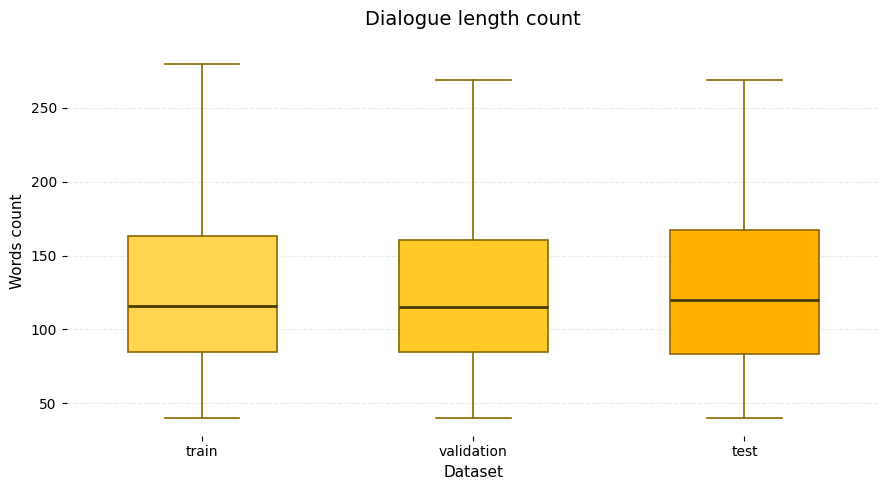

In [41]:
split_names = list(cleaned_eda_splits.keys())

dialogue_lengths = [
    cleaned_eda_splits[split_name]["dialogue_words"].dropna()
    for split_name in split_names
]

yellow_colors = [
    "#FFD54F",
    "#FFCA28",
    "#FFB300",
]

fig, ax = plt.subplots(figsize=(9, 5))

boxplot = ax.boxplot(
    dialogue_lengths,
    tick_labels=split_names,
    showfliers=False,
    patch_artist=True,
    widths=0.55,
)

for box, color in zip(boxplot["boxes"], yellow_colors):
    box.set_facecolor(color)
    box.set_edgecolor("#8A6800")
    box.set_linewidth(1.2)

for median in boxplot["medians"]:
    median.set_color("#4A3900")
    median.set_linewidth(2)

for element in ["whiskers", "caps"]:
    for line in boxplot[element]:
        line.set_color("#8A6800")
        line.set_linewidth(1.2)

ax.set_title(
    "Dialogue length count",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("Words count", fontsize=11)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

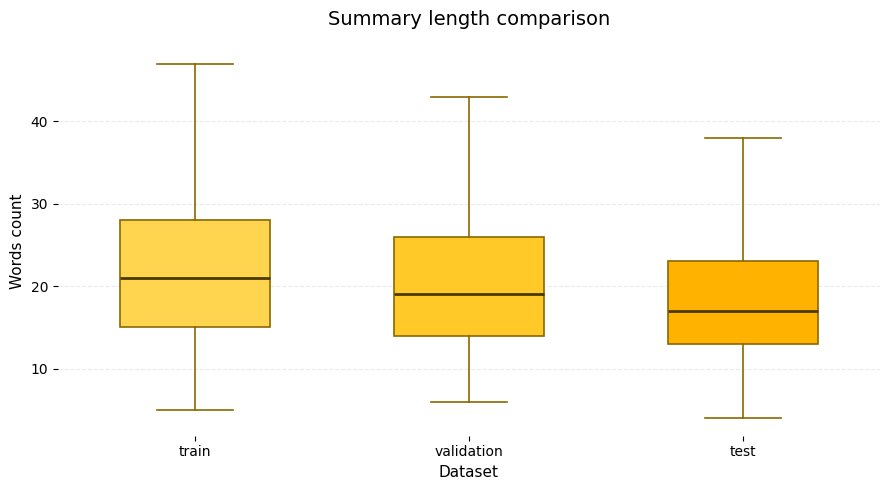

In [40]:
split_names = list(cleaned_eda_splits.keys())

summary_lengths = [
    cleaned_eda_splits[split_name]["summary_words"].dropna()
    for split_name in split_names
]

yellow_colors = [
    "#FFD54F",
    "#FFCA28",
    "#FFB300",
]

fig, ax = plt.subplots(figsize=(9, 5))

boxplot = ax.boxplot(
    summary_lengths,
    tick_labels=split_names,
    showfliers=False,
    patch_artist=True,
    widths=0.55,
)

for box, color in zip(boxplot["boxes"], yellow_colors):
    box.set_facecolor(color)
    box.set_edgecolor("#8A6800")
    box.set_linewidth(1.2)

for median in boxplot["medians"]:
    median.set_color("#4A3900")
    median.set_linewidth(2)

for element in ["whiskers", "caps"]:
    for line in boxplot[element]:
        line.set_color("#8A6800")
        line.set_linewidth(1.2)

ax.set_title(
    "Summary length comparison",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("Words count", fontsize=11)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

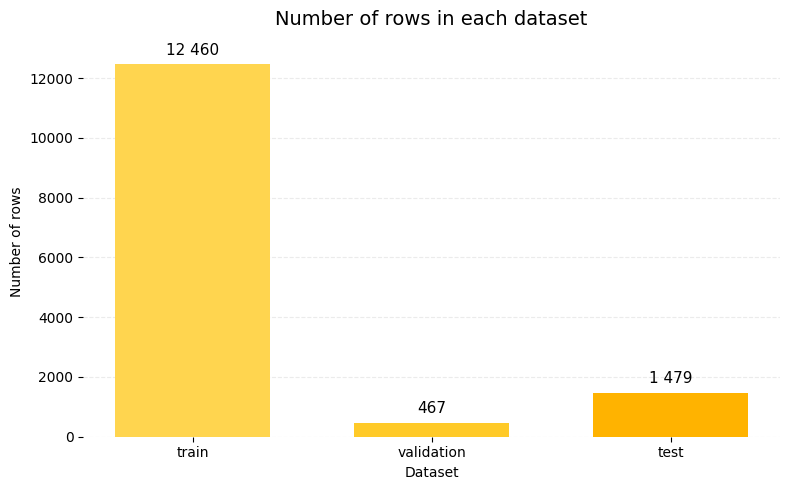

In [ ]:
import matplotlib.pyplot as plt

split_names = list(cleaned_splits.keys())

split_sizes = [
    len(cleaned_splits[split_name])
    for split_name in split_names
]

yellow_colors = [
    "#FFD54F",
    "#FFCA28",
    "#FFB300",
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    split_names,
    split_sizes,
    color=yellow_colors,
    width=0.65,
)

ax.set_title(
    "Number of rows in each dataset",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("Dataset")
ax.set_ylabel("Number of rows")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

for bar, value in zip(bars, split_sizes):
    ax.annotate(
        f"{value:,}".replace(",", " "),
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.tight_layout()
plt.show()